In [7]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.weightstats import ztest

# ==========================================
# 1. LOAD THE DATA
# ==========================================
# Load the CSV file shown in your screenshot
df = pd.read_csv("sms_spam.csv", encoding="latin-1")

# Create a simple numeric column to help us find outliers (length of the message)
df['length'] = df['text'].astype(str).apply(len)

In [8]:
# ==========================================
# 2. BEFORE PREPROCESSING
# ==========================================
print("----- BEFORE PREPROCESSING -----\n")
print("1. Shape:")
print(df.shape)

----- BEFORE PREPROCESSING -----

1. Shape:
(5574, 3)


In [9]:
print("\n2. Data Types:")
print(df.dtypes)


2. Data Types:
type      object
text      object
length     int64
dtype: object


In [10]:
print("\n3. Missing Values:")
print(df.isnull().sum())


3. Missing Values:
type      0
text      0
length    0
dtype: int64


In [11]:
print("\n4. Describe (Summary Statistics):")
print(df.describe())


4. Describe (Summary Statistics):
            length
count  5574.000000
mean     80.563689
std      59.907799
min       2.000000
25%      36.000000
50%      62.000000
75%     122.000000
max     910.000000


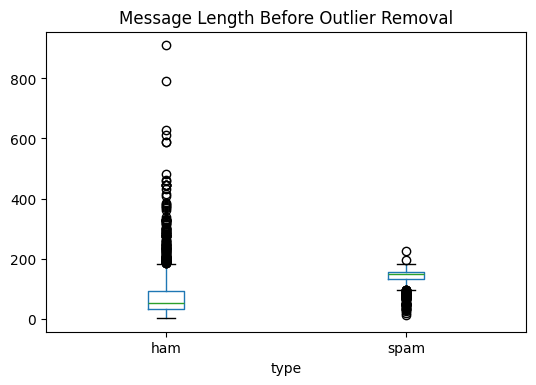

In [12]:
# --- Visualizations Before ---
# 1. Boxplot
df.boxplot(column='length', by='type', grid=False, figsize=(6,4))
plt.title("Message Length Before Outlier Removal")
plt.suptitle("") # Removes default pandas title
plt.show()

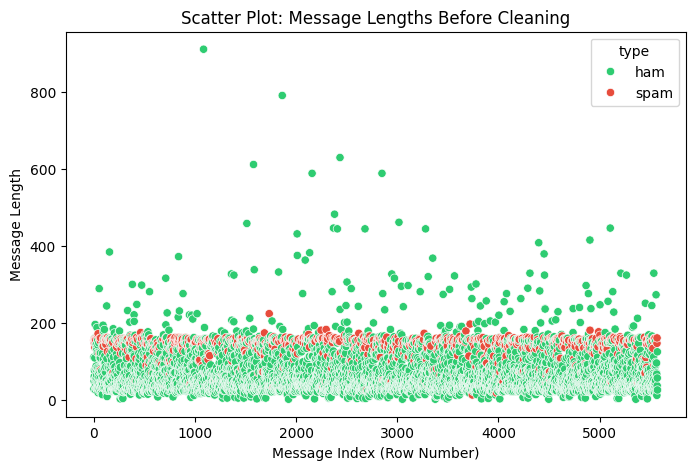

In [13]:
# 2. Scatter Plot
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=df.index, y='length', hue='type', palette=["#2ecc71", "#e74c3c"])
plt.title("Scatter Plot: Message Lengths Before Cleaning")
plt.xlabel("Message Index (Row Number)")
plt.ylabel("Message Length")
plt.show()

In [17]:
# ==========================================
# 3. DO THE PREPROCESSING (Clean the data)
# ==========================================
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
type      0
text      0
length    0
dtype: int64


In [20]:
# ==========================================
# 3. OUTLIER DETECTION AND REMOVAL (Z-SCORE)
# ==========================================
# First handle any true missing values if they exist
df_clean = df.dropna().copy()

In [23]:
# Count total rows before outlier removal
total_rows_before = len(df_clean)
print(f"Total rows before outlier removal: {total_rows_before}")

Total rows before outlier removal: 5510


In [32]:
# Find outliers using Z-score (> 3 standard deviations)
z_scores = abs(stats.zscore(df_clean['length']))

In [33]:
# Filter clean data
df_clean = df_clean[z_scores < 3]
print(f"Max message length before: {df['length'].max()}")
print(f"Max message length after: {df_clean['length'].max()}")

Max message length before: 910
Max message length after: 221


In [27]:
# Count how many outliers were removed
total_rows_after = len(df_clean)
num_outliers_removed = total_rows_before - total_rows_after
print(f"Total outliers removed: {num_outliers_removed}")
print(f"Total rows after outlier removal: {total_rows_after}")

Total outliers removed: 24
Total rows after outlier removal: 5486


In [34]:
# Reset the index so the row numbers are sequential again
df_clean = df_clean.reset_index(drop=True)

In [35]:
print("\n1. Shape (.shape):")
print(df_clean.shape)


1. Shape (.shape):
(5483, 3)


In [36]:
print("\n2. Summary Statistics (.describe()):")
print(df_clean.describe())


2. Summary Statistics (.describe()):
            length
count  5483.000000
mean     76.423126
std      48.604612
min       2.000000
25%      35.000000
50%      60.000000
75%     119.000000
max     221.000000


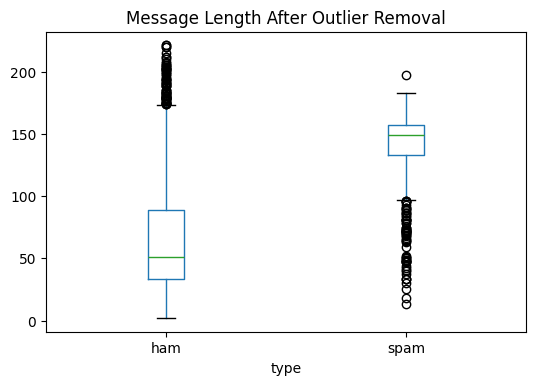

In [37]:
# 1. Boxplot After Outlier Removal
df_clean.boxplot(column='length', by='type', grid=False, figsize=(6,4))
plt.title("Message Length After Outlier Removal")
plt.suptitle("")
plt.show()

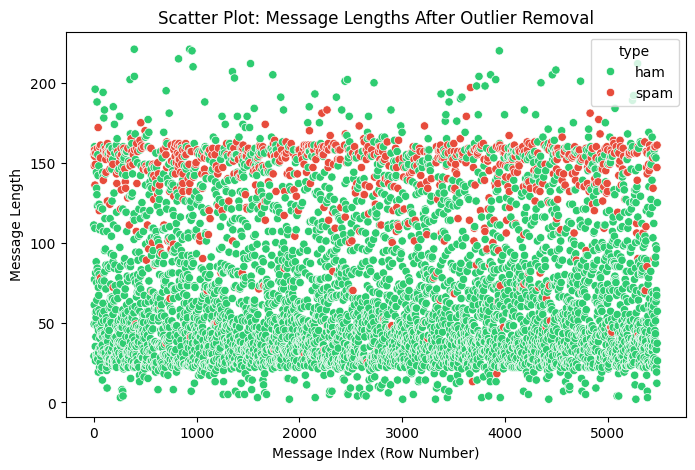

In [38]:
# 2. Scatter Plot After Outlier Removal
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x=df_clean.index, y='length', hue='type', palette=["#2ecc71", "#e74c3c"])
plt.title("Scatter Plot: Message Lengths After Outlier Removal")
plt.xlabel("Message Index (Row Number)")
plt.ylabel("Message Length")
plt.show()

In [39]:
# ==========================================
# 5. STATISTICAL ANALYSIS (Z-TEST)
# ==========================================
print("==========================================")
print("           Z-TEST ANALYSIS")
print("==========================================\n")

spam_lengths = df_clean[df_clean['type'] == 'spam']['length']
ham_lengths = df_clean[df_clean['type'] == 'ham']['length']

z_stat, p_value = ztest(spam_lengths, ham_lengths)

print(f"Z-Statistic: {z_stat:.2f}")
print(f"P-Value: {p_value}")

if p_value < 0.05:
    print("\nConclusion: Because the P-Value is less than 0.05, we reject the null hypothesis.")
    print("This mathematically proves there is a significant difference in length between Spam and Ham messages!")
else:
    print("\nConclusion: There is no significant difference in length between Spam and Ham messages.")

           Z-TEST ANALYSIS

Z-Statistic: 43.98
P-Value: 0.0

Conclusion: Because the P-Value is less than 0.05, we reject the null hypothesis.
This mathematically proves there is a significant difference in length between Spam and Ham messages!
